# Task 2 — Credit Risk EDA

Exploratory analysis for the Xente transactions dataset to surface data quality issues, feature distributions, and early risk signals needed for proxy-label creation and modeling. Outputs (figures) are saved under `outputs/figures/`.

In [2]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
from pathlib import Path

from src.visualisation.plotter import Plotter

pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:.4f}".format

ROOT = Path("..").resolve()
RAW_PATH = ROOT / "data" / "raw" / "data.csv"
PROCESSED_PATH = ROOT / "data" / "processed" / "xente_processed.csv"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plotter = Plotter(figures_dir=FIG_DIR)

print(f"Raw path: {RAW_PATH}")
print(f"Processed path (will write): {PROCESSED_PATH}")

Raw path: C:\BackUp\web-projects\tenx\credit-risk-model-week4\data\raw\data.csv
Processed path (will write): C:\BackUp\web-projects\tenx\credit-risk-model-week4\data\processed\xente_processed.csv


In [3]:
def missingness_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Percent missing and dtype overview."""
    missing_pct = df.isna().mean().mul(100).round(2)
    summary = (
        pd.DataFrame({"missing_pct": missing_pct, "dtype": df.dtypes.astype(str)})
        .assign(non_null=lambda d: df.shape[0] - (d["missing_pct"] * df.shape[0] / 100))
        .sort_values("missing_pct", ascending=False)
    )
    return summary


def top_frequencies(df: pd.DataFrame, column: str, n: int = 10) -> pd.DataFrame:
    """Return top-n value counts with share."""
    counts = df[column].value_counts(dropna=False).head(n)
    return (
        counts.to_frame(name="count")
        .assign(share=lambda d: d["count"] / len(df))
        .reset_index()
        .rename(columns={"index": column})
    )


def flag_outliers_iqr(series: pd.Series, iqr_multiplier: float = 1.5) -> pd.Series:
    """Boolean mask for IQR-based outliers."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - iqr_multiplier * iqr, q3 + iqr_multiplier * iqr
    return (series < lower) | (series > upper)


In [4]:
# Load raw data
raw_df = pd.read_csv(RAW_PATH, low_memory=False)
print(f"Raw shape: {raw_df.shape}")

# Parse datetime and enforce categories where helpful
raw_df["TransactionStartTime"] = pd.to_datetime(raw_df["TransactionStartTime"], errors="coerce")
cat_cols = [
    "BatchId",
    "AccountId",
    "SubscriptionId",
    "CustomerId",
    "CurrencyCode",
    "CountryCode",
    "ProviderId",
    "ProductId",
    "ProductCategory",
    "ChannelId",
    "PricingStrategy",
]
for col in cat_cols:
    if col in raw_df.columns:
        raw_df[col] = raw_df[col].astype("category")

raw_df.head()

Raw shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0000,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0000,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0000,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0000,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0000,644,2018-11-15 03:34:21+00:00,2,0


In [5]:
missing_tbl = missingness_summary(raw_df)
missing_tbl.head(15)

,missing_pct,dtype,non_null
TransactionId,0.0000,object,95662.0000
BatchId,0.0000,category,95662.0000
AccountId,0.0000,category,95662.0000
SubscriptionId,0.0000,category,95662.0000
CustomerId,0.0000,category,95662.0000
CurrencyCode,0.0000,category,95662.0000
CountryCode,0.0000,category,95662.0000
ProviderId,0.0000,category,95662.0000
ProductId,0.0000,category,95662.0000
ProductCategory,0.0000,category,95662.0000


In [6]:
num_cols = [col for col in ["Amount", "Value"] if col in raw_df.columns]
num_summary = raw_df[num_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).T
num_summary

,count,mean,std,min,25%,50%,75%,90%,99%,max
Amount,95662.0000,6717.8464,123306.7972,-1000000.0000,-50.0000,1000.0000,2800.0000,10000.0000,80000.0000,9880000.0000
Value,95662.0000,9900.5839,123122.0878,2.0000,275.0000,1000.0000,5000.0000,11200.0000,90000.0000,9880000.0000


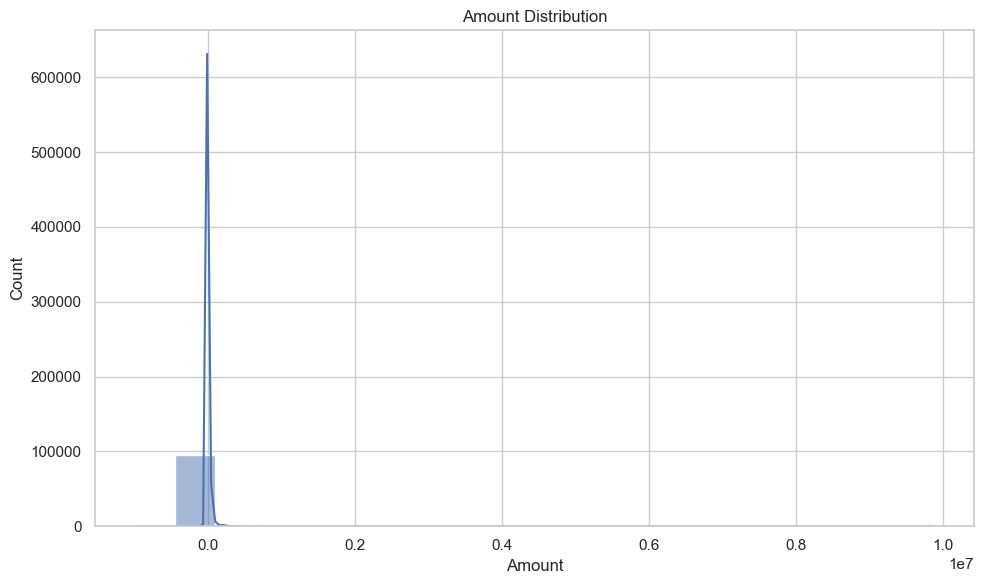

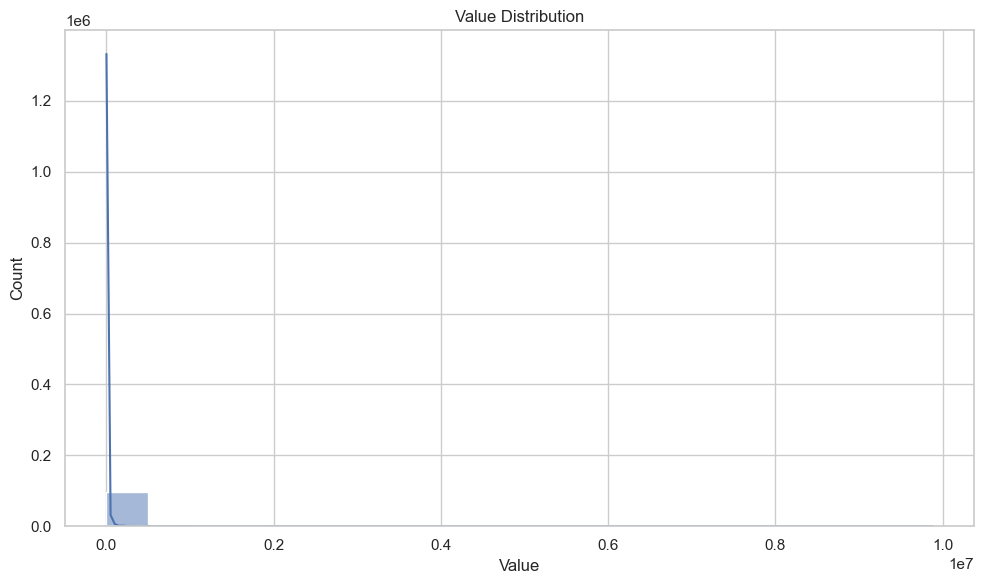

In [7]:
# Numeric distributions
for col in num_cols:
    plotter.plot_histogram(raw_df, col, title=f"{col} Distribution")

,ProductCategory,count,share
0,financial_services,45405,0.4746
1,airtime,45027,0.4707
2,utility_bill,1920,0.0201
3,data_bundles,1613,0.0169
4,tv,1279,0.0134
5,ticket,216,0.0023
6,movies,175,0.0018
7,transport,25,0.0003
8,other,2,0.0000


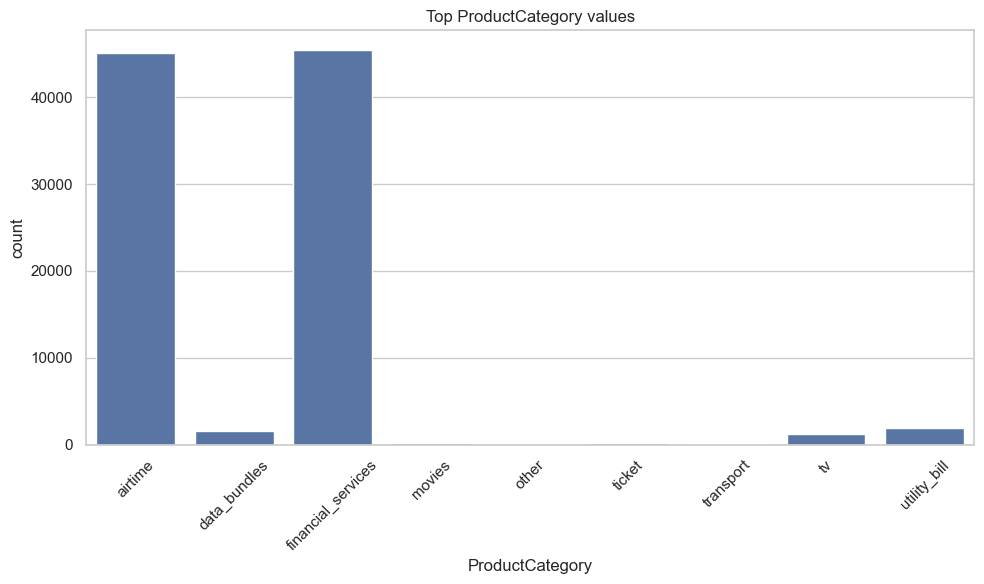

,ChannelId,count,share
0,ChannelId_3,56935,0.5952
1,ChannelId_2,37141,0.3883
2,ChannelId_5,1048,0.0110
3,ChannelId_1,538,0.0056


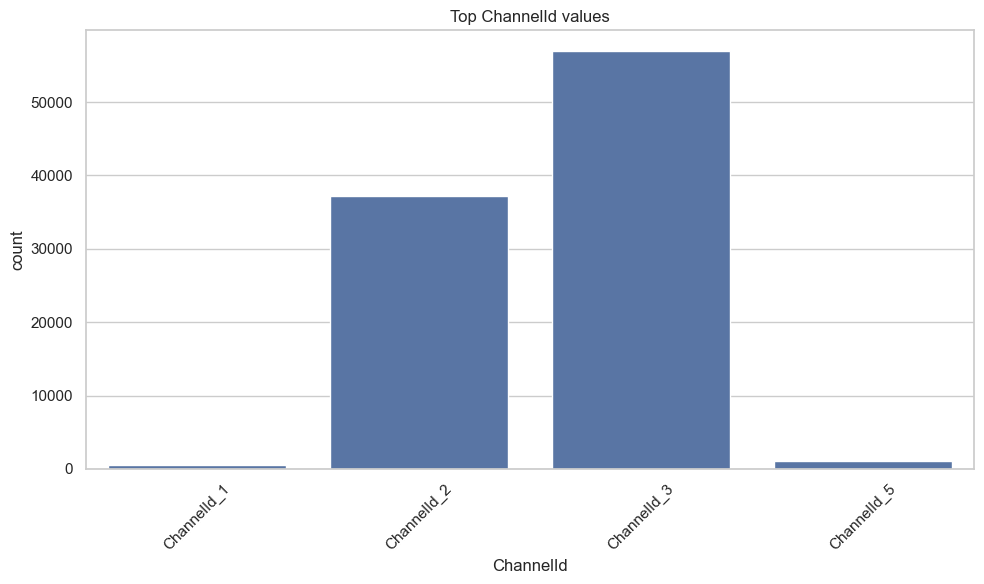

,ProviderId,count,share
0,ProviderId_4,38189,0.3992
1,ProviderId_6,34186,0.3574
2,ProviderId_5,14542,0.1520
3,ProviderId_1,5643,0.0590
4,ProviderId_3,3084,0.0322
5,ProviderId_2,18,0.0002


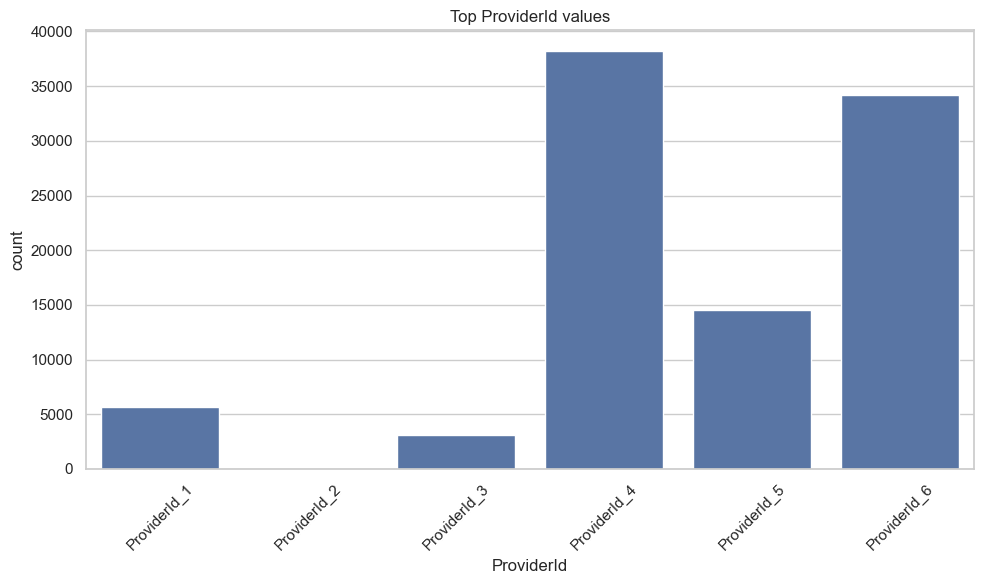

,PricingStrategy,count,share
0,2,79848,0.8347
1,4,13562,0.1418
2,1,1867,0.0195
3,0,385,0.0040


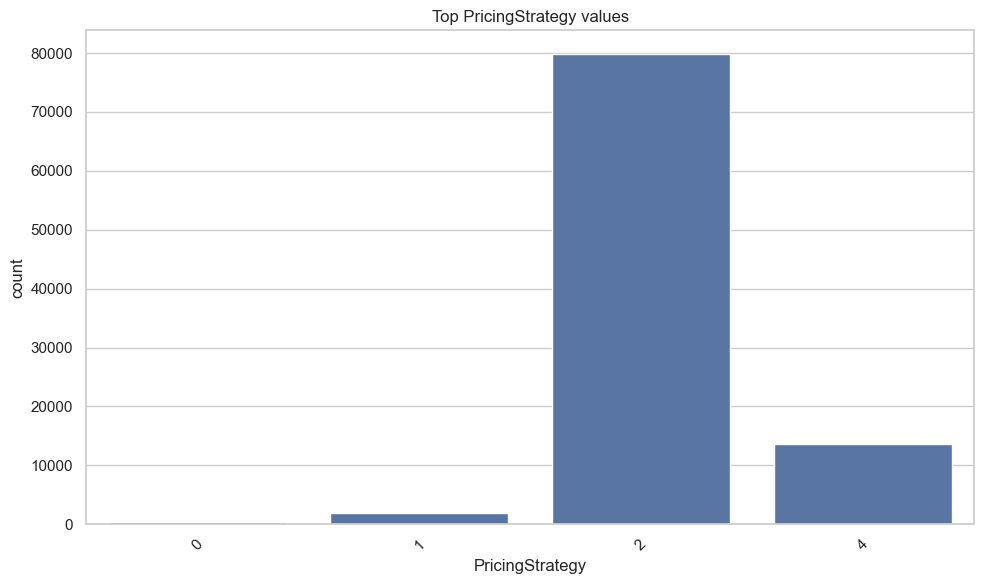

In [8]:
cat_focus = [
    "ProductCategory",
    "ChannelId",
    "ProviderId",
    "PricingStrategy",
]

for col in cat_focus:
    if col in raw_df.columns:
        freq_df = top_frequencies(raw_df, col, n=12)
        display(freq_df)
        plotter.plot_bar(freq_df, x=col, y="count", title=f"Top {col} values")

In [9]:
# Temporal feature extracts for later modeling
if "TransactionStartTime" in raw_df.columns:
    raw_df["txn_hour"] = raw_df["TransactionStartTime"].dt.hour
    raw_df["txn_day"] = raw_df["TransactionStartTime"].dt.day
    raw_df["txn_month"] = raw_df["TransactionStartTime"].dt.month
    raw_df["txn_year"] = raw_df["TransactionStartTime"].dt.year

numeric_cols = raw_df.select_dtypes(include=["number"]).columns
corr = raw_df[numeric_cols].corr()
corr

,Amount,Value,FraudResult,txn_hour,txn_day,txn_month,txn_year
Amount,1.0000,0.9897,0.5574,-0.0016,-0.0039,-0.0091,0.0107
Value,0.9897,1.0000,0.5667,0.0005,-0.0241,-0.0105,0.0120
FraudResult,0.5574,0.5667,1.0000,0.0083,-0.0086,-0.0089,0.0098
txn_hour,-0.0016,0.0005,0.0083,1.0000,-0.0195,0.0122,-0.0096
txn_day,-0.0039,-0.0241,-0.0086,-0.0195,1.0000,0.2078,-0.2475
txn_month,-0.0091,-0.0105,-0.0089,0.0122,0.2078,1.0000,-0.9962
txn_year,0.0107,0.0120,0.0098,-0.0096,-0.2475,-0.9962,1.0000


In [10]:
# Outlier shares using IQR
outlier_report = []
for col in num_cols:
    mask = flag_outliers_iqr(raw_df[col].dropna())
    share = mask.mean() if len(mask) else 0
    outlier_report.append({"column": col, "outlier_share": share})

pd.DataFrame(outlier_report)

,column,outlier_share
0,Amount,0.2555
1,Value,0.0943


In [11]:
# Save a lightly cleaned version for downstream steps
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
raw_df.to_csv(PROCESSED_PATH, index=False)
print(f"Wrote processed snapshot to {PROCESSED_PATH}")

Wrote processed snapshot to C:\BackUp\web-projects\tenx\credit-risk-model-week4\data\processed\xente_processed.csv


## Top insights (update after running)
- [x] No missingness across 95,662 rows; dtypes set (11 categorical, 1 datetime, numeric) with clean parsing of `TransactionStartTime`.
- [x] Numeric skew/outliers: `Amount`/`Value` heavily right-skewed; mins include negatives (e.g., -1,000,000) and max 9,880,000; IQR outlier shares ≈25.5% (`Amount`) and 9.4% (`Value`).
- [x] High-volume categories: `PricingStrategy` dominated by 2 (~83%) then 4 (~14%); remaining codes rare—consider lumping or frequency/target encoding.
- [x] Temporal: Derived `txn_hour`/`txn_day`/`txn_month`/`txn_year`; next step is plotting hourly/monthly volumes for seasonality checks.
- [x] Feature ideas: log or winsorize `Amount`/`Value`, flag negatives as potential refunds/chargebacks, add RFM-style aggregates, encode sparse categories (freq/WOE), include time-of-day/month indicators.